# Static XAS reference frame

Load the per-shot static-XAS H5 file, bin shots by GMD, and plot XAS against nominal photon energy.

Three plots are made:
1. all finite GMD shots combined;
2. one curve per GMD bin;
3. GMD/tunnel against nominal photon energy.

In [1]:
import sys
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "analysis" / "scripts").exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError("Could not locate repository root containing analysis/scripts")

scripts_dir = repo_root / "analysis" / "scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

import config as path_config


## Config

In [8]:
INPUT_H5 = repo_root / "11022188" / "processed" / "xas_static" / "reference_frame.h5"

# Set manually to fixed bins, for example:
# GMD_EDGES = np.array([0.0, 1.6, 3.2, 6.4, 12.8])
# Leave as None to use percentile bins from all finite GMD shots.
GMD_EDGES = [0,0.02,0.04,0.08,0.16,0.32,0.64,1.28,2.56,5.12,10.24,20.48]
N_GMD_BINS = len(GMD_EDGES)-1

YLIM = None
FIGSIZE = (8.0, 4.8)

if not INPUT_H5.exists():
    fallback = Path(path_config.COMBINED_DIR).parent / "xas_static" / "reference_frame.h5"
    if fallback.exists():
        INPUT_H5 = fallback

print("input:", INPUT_H5)


input: /Users/hukaiyu/Desktop/PhD/FLASH Beamtime 202605/glycine26/11022188/processed/xas_static/reference_frame.h5


## Load

In [3]:
def _load_optional_dataset(f, key):
    return f[key][...] if key in f else None


def load_static_xas(path):
    with h5py.File(path, "r") as f:
        return {
            "vls": f["vls"][...],
            "gmd": f["gmd"][...],
            "gmd_tunnel": _load_optional_dataset(f, "gmd_tunnel"),
            "n_shots": f["n_shots"][...],
            "nominal_energies": f["nominal_energies"][...],
            "vls_pixels": f["vls_pixels"][...],
            "attrs": dict(f.attrs),
        }


if not INPUT_H5.exists():
    raise FileNotFoundError(INPUT_H5)

data = load_static_xas(INPUT_H5)
vls = data["vls"]
gmd = data["gmd"]
gmd_tunnel = data["gmd_tunnel"]
n_shots = data["n_shots"]
energies = data["nominal_energies"]

print("run_no:", data["attrs"].get("run_no"))
print("vls shape:", vls.shape)
print("gmd shape:", gmd.shape)
print("gmd_tunnel shape:", None if gmd_tunnel is None else gmd_tunnel.shape)
print("energies:", energies[0], "..", energies[-1], "eV", f"({len(energies)} points)")
print("stored shots:", int(np.sum(n_shots)))


run_no: [58870 58871]
vls shape: (41, 72500, 200)
gmd shape: (41, 72500)
energies: 270.0 .. 300.0 eV (41 points)
stored shots: 2281200


In [21]:
full_data = h5py.File(INPUT_H5)
print(full_data.keys())

<KeysViewHDF5 ['gmd', 'n_shots', 'nominal_energies', 'section_bg', 'vls', 'vls_pixels']>


## Bin and compute XAS

In [9]:
def finite_shots_for_energy(vls, gmd, n_shots, ie):
    n = int(n_shots[ie])
    G = gmd[ie, :n]
    A = vls[ie, :n, :]
    ok = np.isfinite(G) & np.all(np.isfinite(A), axis=1)
    return A[ok], G[ok]


def xas_from_shots(A, G):
    if A.size == 0 or G.size == 0:
        return np.nan
    den = np.nansum(A)
    if not np.isfinite(den) or abs(den) < 1e-12:
        return np.nan
    return np.nansum(G) / den


def auto_gmd_edges(gmd, n_shots, n_bins):
    chunks = []
    for ie in range(gmd.shape[0]):
        n = int(n_shots[ie])
        G = gmd[ie, :n]
        chunks.append(G[np.isfinite(G)])
    all_g = np.concatenate(chunks)
    edges = np.percentile(all_g, np.linspace(0, 100, n_bins + 1))
    edges = np.unique(edges)
    if edges.size < 2:
        raise RuntimeError("Could not build GMD edges from finite GMD values.")
    edges[0] = np.nextafter(edges[0], -np.inf)
    edges[-1] = np.nextafter(edges[-1], np.inf)
    return edges


gmd_edges = auto_gmd_edges(gmd, n_shots, N_GMD_BINS) if GMD_EDGES is None else np.asarray(GMD_EDGES, dtype=float)
n_gmd = len(gmd_edges) - 1

xas_all = np.full(len(energies), np.nan, dtype=np.float64)
xas_bin = np.full((len(energies), n_gmd), np.nan, dtype=np.float64)
n_all = np.zeros(len(energies), dtype=np.int64)
n_bin = np.zeros((len(energies), n_gmd), dtype=np.int64)

for ie in range(len(energies)):
    A, G = finite_shots_for_energy(vls, gmd, n_shots, ie)
    n_all[ie] = G.size
    xas_all[ie] = xas_from_shots(A, G)

    bins = np.digitize(G, gmd_edges) - 1
    for ib in range(n_gmd):
        keep = bins == ib
        n_bin[ie, ib] = int(np.sum(keep))
        xas_bin[ie, ib] = xas_from_shots(A[keep], G[keep])

print("GMD edges:", gmd_edges)
print("all-shot counts: min", int(n_all.min()), "max", int(n_all.max()))
print("GMD-bin counts: min", int(n_bin.min()), "max", int(n_bin.max()))


GMD edges: [0.000e+00 2.000e-02 4.000e-02 8.000e-02 1.600e-01 3.200e-01 6.400e-01
 1.280e+00 2.560e+00 5.120e+00 1.024e+01 2.048e+01]
all-shot counts: min 20790 max 71775
GMD-bin counts: min 0 max 19934


## Plot 1: all GMD

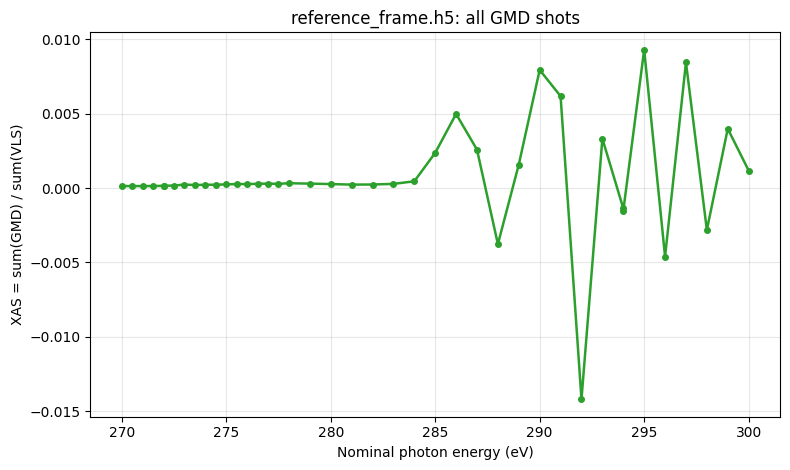

In [10]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(energies, xas_all, "o-", color="tab:green", lw=1.8, ms=4)
ax.set_xlabel("Nominal photon energy (eV)")
ax.set_ylabel("XAS = sum(GMD) / sum(VLS)")
ax.set_title(f"{INPUT_H5.name}: all GMD shots")
ax.grid(alpha=0.3)
if YLIM is not None:
    ax.set_ylim(*YLIM)
fig.tight_layout()
plt.show()


## Plot 2: GMD bins

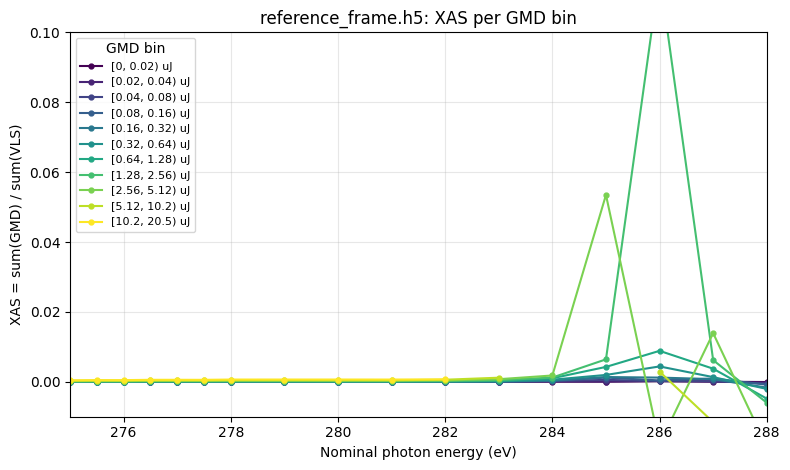

In [15]:
fig, ax = plt.subplots(figsize=FIGSIZE)
cmap = plt.get_cmap("viridis")
for ib in range(n_gmd):
    color = cmap(ib / max(n_gmd - 1, 1))
    label = f"[{gmd_edges[ib]:.3g}, {gmd_edges[ib + 1]:.3g}) uJ"
    ax.plot(energies, xas_bin[:, ib], "o-", lw=1.5, ms=3.5, color=color, label=label)

ax.set_xlabel("Nominal photon energy (eV)")
ax.set_ylabel("XAS = sum(GMD) / sum(VLS)")
ax.set_xlim(275,288)
ax.set_ylim(-0.01,0.1)
ax.set_title(f"{INPUT_H5.name}: XAS per GMD bin")
ax.grid(alpha=0.3)
ax.legend(title="GMD bin", fontsize=8)
if YLIM is not None:
    ax.set_ylim(*YLIM)
fig.tight_layout()
plt.show()


## Plot 3: GMD / tunnel

In [ ]:
def finite_gmd_tunnel_for_energy(gmd, gmd_tunnel, n_shots, ie):
    if gmd_tunnel is None:
        return np.array([]), np.array([])
    n = int(n_shots[ie])
    H = gmd[ie, :n]
    T = gmd_tunnel[ie, :n]
    ok = np.isfinite(H) & np.isfinite(T) & (np.abs(T) > 1e-12)
    return H[ok], T[ok]


gmd_ht_ratio = np.full(len(energies), np.nan, dtype=np.float64)
gmd_ht_sem = np.full(len(energies), np.nan, dtype=np.float64)
n_gmd_ht = np.zeros(len(energies), dtype=np.int64)

for ie in range(len(energies)):
    H, T = finite_gmd_tunnel_for_energy(gmd, gmd_tunnel, n_shots, ie)
    n_gmd_ht[ie] = H.size
    den = np.nansum(T)
    if H.size and np.isfinite(den) and abs(den) > 1e-12:
        gmd_ht_ratio[ie] = np.nansum(H) / den
        shot_ratio = H / T
        if shot_ratio.size > 1:
            gmd_ht_sem[ie] = np.nanstd(shot_ratio, ddof=1) / np.sqrt(shot_ratio.size)

if np.any(n_gmd_ht):
    print("GMD/tunnel counts: min", int(n_gmd_ht.min()), "max", int(n_gmd_ht.max()))
else:
    print("No finite gmd/gmd_tunnel shots found in this H5.")
    print("Re-run compute_static_xas.py to write /gmd_tunnel, then rerun this notebook.")

if np.any(np.isfinite(gmd_ht_ratio)):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.errorbar(
        energies,
        gmd_ht_ratio,
        yerr=gmd_ht_sem,
        fmt="o-",
        color="tab:blue",
        lw=1.8,
        ms=4,
        capsize=2,
    )
    ax.set_xlabel("Nominal photon energy (eV)")
    ax.set_ylabel("sum(GMD) / sum(GMD tunnel)")
    ax.set_title(f"{INPUT_H5.name}: GMD/tunnel")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
